# 말벌 포함 여부 이진분류 학습 — 혼합음 대체 수정본

- non_wasp=0: 말벌이 없는 꿀벌/환경음. wasp=1: 말벌 단독 또는 말벌 포함 혼합음.
- 말벌 Train의 일부를 혼합음으로 **대체**합니다. 원본 WAV와 클래스별 학습 개수는 유지합니다.
- 혼합은 Train에서만 수행하며 Validation/Test와 시연 음원에는 적용하지 않습니다.
- 데이터 배치: `audio/<클래스>/<원본ID>/*.wav` (라벨을 확인한 2초 이하 구간).
- 학습 전에 `mixing_summary.json`, `mixing_manifest.csv` 및 필수 점검 셀을 확인하세요.
- 원본ID 분할은 파일명만으로 독립성을 보장하지 않습니다. 실제 녹음 출처를 확인해야 합니다.
- `src/`의 공통 전처리·추론 코드는 별도 파일이며 이 노트북에 포함되어 있지 않습니다.
- 새 모델은 `models/`에 저장됩니다.
- 커널 재시작 후 위에서부터 실행. 임계값 변경 시 평가도 다시 실행하세요.


In [ ]:
%pip install --upgrade pip

In [ ]:
! pip install numpy pandas matplotlib seaborn librosa pillow scikit-learn tensorflow image lightgbm xgboost

In [ ]:
%pip list

# 1. 환경 설정

In [1]:
# 저장소 루트 또는 ai_model에서 실행 가능
import sys
from pathlib import Path
notebook_root = Path.cwd() if (Path.cwd() / 'src' / 'config.py').is_file() else Path.cwd() / 'ai_model'
if not (notebook_root / 'src' / 'config.py').is_file():
    raise RuntimeError('Buzz 또는 ai_model 폴더에서 노트북을 실행하세요.')
sys.path.insert(0, str(notebook_root))
import os                           # 폴더 / 파일 경로 처리
import glob                         # 특정 패턴의 파일 검색 (예: .wav .mp3 등)
import random                       # 랜덤 샘플 선택

import numpy as np                  # 오디오 파형, 행렬 계산
import pandas as pd                 # 데이터프레임
import matplotlib.pyplot as plt     # 그래프 (시각화)
import seaborn as sns               # confusion matrix 등 시각화
%matplotlib inline

import librosa                      # wav 로딩, waveform, FFT/STFT, Mel Spectrogram, MFCC 등 대부분 처리
import librosa.display

import joblib

from sklearn.metrics import (       # 모델 성능 평가
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# 머신러닝 3종
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 데이터 분할
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# 딥러닝 (CNN, CRNN, MobileNetV2)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2

# 랜덤 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 경고 메시지 무시
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 학습과 추론이 같은 클래스 순서, 전처리, 저장 경로를 사용한다.
from src.config import (
    BASE_DIR, AUDIO_DIR, MODEL_DIR, CLASSES, WASP_INDEX, WASP_THRESHOLD,
    SR, DURATION, SAMPLES_PER_TRACK, TARGET_DB,
    IMG_HEIGHT, IMG_WIDTH, N_FFT, HOP_LENGTH, N_MELS,
)
from src.binary_classification import predict_classes, ordered_ml_probabilities
from src.dataset import collect_audio_files, split_by_source

BATCH_SIZE = 16
EPOCHS = 50
print('Classes:', dict(enumerate(CLASSES)))
print('Audio:', AUDIO_DIR)
print('Binary models:', MODEL_DIR)
print('Wasp threshold:', WASP_THRESHOLD)

Classes: {0: 'non_wasp', 1: 'wasp'}
Audio: E:\AI_First_Team_Project\Buzz\ai_model\audio
Binary models: E:\AI_First_Team_Project\Buzz\ai_model\models
Wasp threshold: 0.5


# 2. 데이터셋 확인 및 기본 유틸리티

In [3]:
def ensure_directory_exists(dir_path):
    Path(dir_path).mkdir(parents=True, exist_ok=True)

# audio/non_wasp/<원본ID>/*.wav, audio/wasp/<원본ID>/*.wav
# 말벌 단독/혼합 모두 wasp. 2초 이하로 잘라 구간별 라벨을 확인한다.
records = collect_audio_files(AUDIO_DIR)

,Class,Count,Ratio
0,non_wasp,1000,0.5
1,wasp,1000,0.5


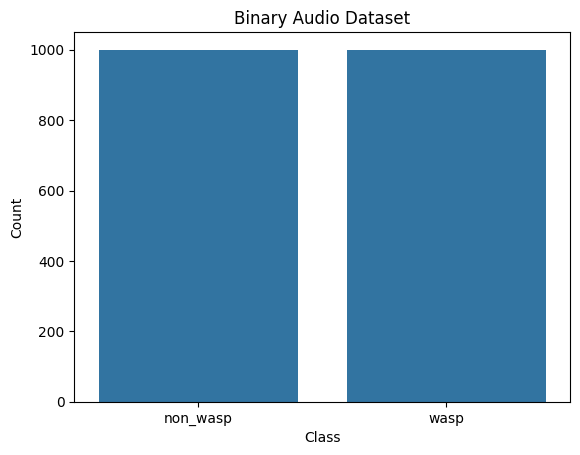

In [4]:
file_counts = {cls: sum(row['label'] == i for row in records) for i, cls in enumerate(CLASSES)}
file_counts_df = pd.DataFrame(list(file_counts.items()), columns=['Class', 'Count'])
file_counts_df['Ratio'] = file_counts_df['Count'] / file_counts_df['Count'].sum()
display(file_counts_df)
sns.barplot(data=file_counts_df, x='Class', y='Count')
plt.title('Binary Audio Dataset')
plt.show()

# 3. 오디오 전처리 및 EDA

In [5]:
from src.audio_preprocessing import load_audio_file, normalize_rms
# 랜덤 crop 없이 학습과 추론에서 동일한 2초 전처리를 사용한다.


In [6]:
sample_files = {
    cls: next(row['path'] for row in records if row['label'] == i)
    for i, cls in enumerate(CLASSES)
}
for cls, audio_path in sample_files.items():
    y_sample, sr_sample = load_audio_file(audio_path)
    print(cls, audio_path, sr_sample, len(y_sample))

non_wasp E:\AI_First_Team_Project\Buzz\ai_model\audio\non_wasp\bee2\bee2_001.wav 24000 48000
wasp E:\AI_First_Team_Project\Buzz\ai_model\audio\wasp\vespa\vespa_2s_0001.wav 24000 48000


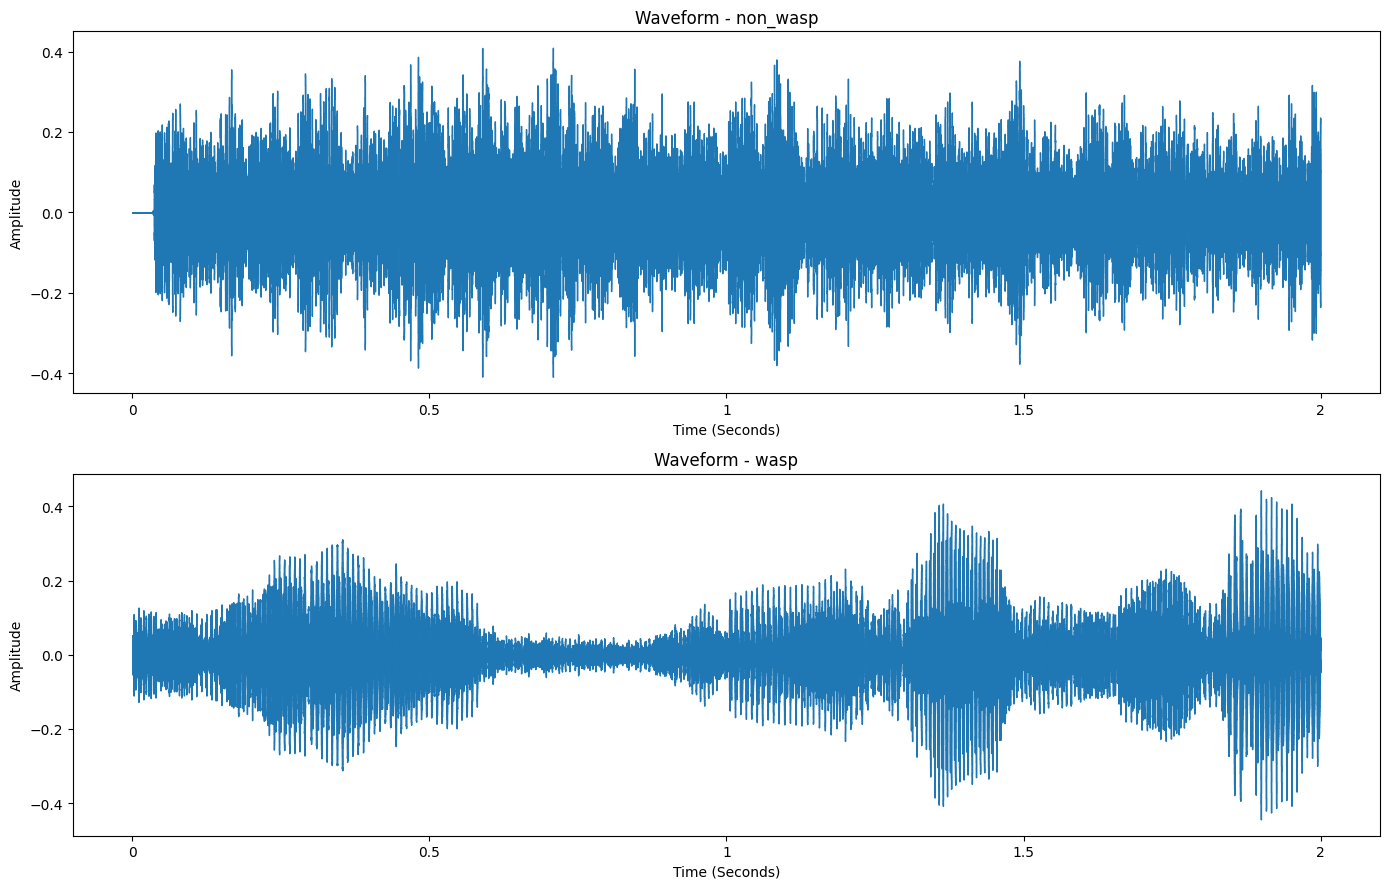

In [7]:
plt.figure(figsize = (14, 9))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    plt.subplot(len(CLASSES), 1, i)

    librosa.display.waveshow(y_sample, sr = sr_sample)

    plt.title(f'Waveform - {cls}')
    plt.xlabel('Time (Seconds)')
    plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

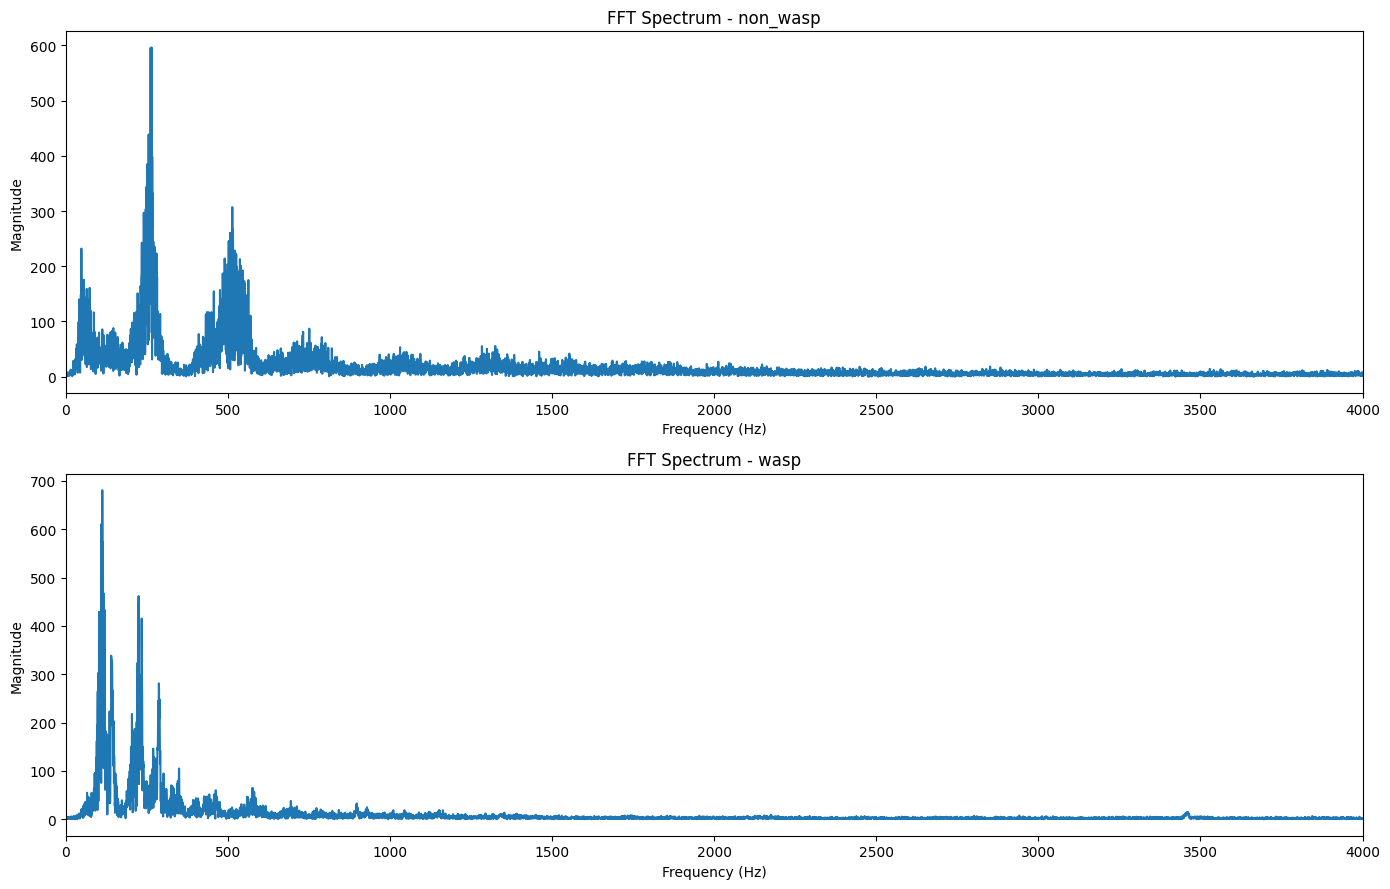

In [8]:
plt.figure(figsize = (14, 9))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    # 실수 Audio 신호용 FFT
    fft_sample = np.fft.rfft(y_sample)

    # Magnitude Spectrum
    magnitude_sample = np.abs(fft_sample)

    # Frequency Axis
    freqs_sample = np.fft.rfftfreq(len(y_sample), d = 1 / sr_sample)

    plt.subplot(len(CLASSES), 1, i)

    plt.plot(freqs_sample, magnitude_sample)

    plt.title(f'FFT Spectrum - {cls}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')

    plt.xlim(0, sr_sample / 6)

plt.tight_layout()
plt.show()

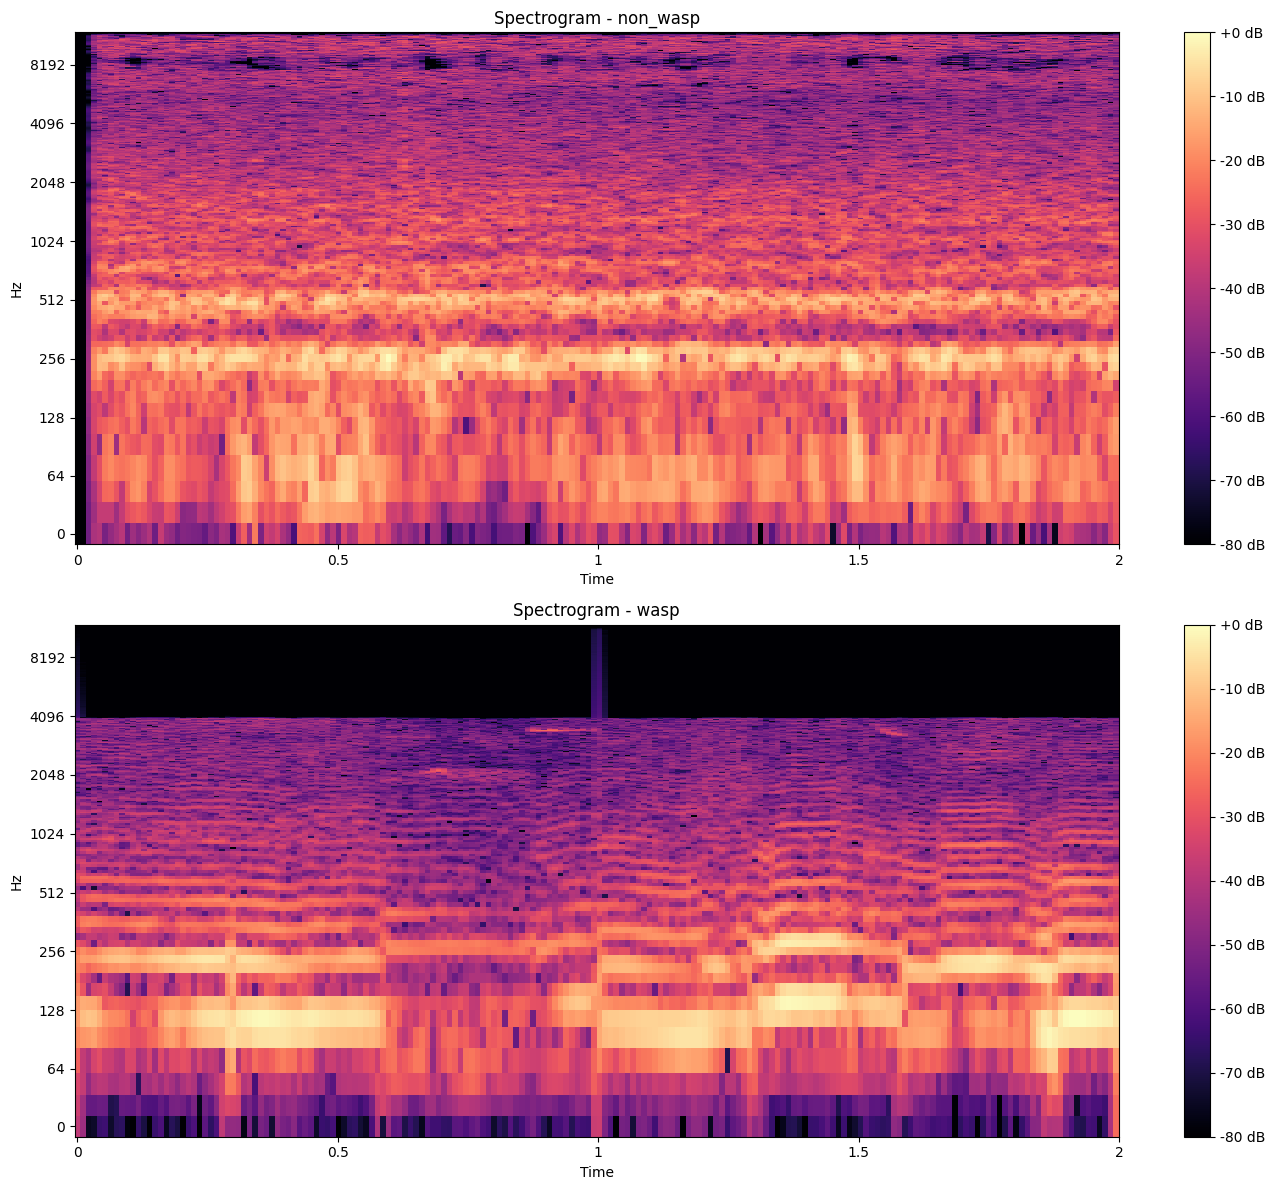

In [9]:
plt.figure(figsize = (14, 12))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    # STFT
    stft_sample = librosa.stft(y_sample, n_fft = N_FFT, hop_length = HOP_LENGTH)

    # Magnitude Spectrogram
    spectrogram_sample = np.abs(stft_sample)

    # dB 변환
    spectrogram_db_sample = librosa.amplitude_to_db(spectrogram_sample, ref = np.max)

    plt.subplot(len(CLASSES), 1, i)

    img = librosa.display.specshow(
        spectrogram_db_sample,
        sr = sr_sample,
        hop_length = HOP_LENGTH,
        x_axis = 'time',
        y_axis = 'log',
        cmap = 'magma'
    )

    plt.colorbar(img, format = '%+2.0f dB')
    plt.title(f'Spectrogram - {cls}')

plt.tight_layout()
plt.show()

# 4. Deep Learning

## 4-1. Mel-Spectrogram 데이터셋 구성

In [10]:
from src.audio_preprocessing import create_mel_spectrogram_from_audio
from src.feature_extraction import extract_audio_features_from_audio

In [11]:
# 같은 파형에서 DL/ML 특징을 함께 생성하여 구간·라벨·순서를 일치시킨다.
mel_data, ml_features = [], []
for row in records:
    y_audio, sr_audio = load_audio_file(row['path'])
    mel_data.append(create_mel_spectrogram_from_audio(y_audio, sr_audio))
    ml_features.append(extract_audio_features_from_audio(y_audio, sr_audio))

X_mel = np.asarray(mel_data, dtype=np.float32)
y_mel = np.asarray([row['label'] for row in records], dtype=np.int32)
mel_file_paths = np.asarray([row['path'] for row in records])
source_ids = np.asarray([row['source_id'] for row in records])
X_ml = np.asarray(ml_features, dtype=np.float32)
y_ml = y_mel.copy()
ml_file_paths = mel_file_paths.copy()
print('Mel:', X_mel.shape, 'ML:', X_ml.shape, 'Labels:', y_mel.shape)

Mel: (2000, 128, 188) ML: (2000, 74) Labels: (2000,)


In [12]:
# 원본 영상/녹음 단위 분리. 같은 원본의 잘린 구간은 하나의 split에만 포함된다.
train_indices, val_indices, test_indices = split_by_source(y_mel, source_ids, seed=SEED)
X_train_mel, X_val_mel, X_test_mel = [X_mel[i] for i in (train_indices, val_indices, test_indices)]
y_train_mel, y_val_mel, y_test_mel = [y_mel[i] for i in (train_indices, val_indices, test_indices)]
paths_train_mel, paths_val_mel, paths_test_mel = [mel_file_paths[i] for i in (train_indices, val_indices, test_indices)]

# 학습 세트만으로 클래스 불균형 보정. 말벌=1을 양성으로 취급한다.
class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.arange(2), y=y_train_mel)))
for name, indices in zip(('Train', 'Validation', 'Test'), (train_indices, val_indices, test_indices)):
    print(name, 'segments:', len(indices), 'sources:', len(set(source_ids[indices])),
          {cls: int(np.sum(y_mel[indices] == i)) for i, cls in enumerate(CLASSES)})

# 재현/누수 점검용 분할 목록 저장(음원은 이동하지 않는다).
ensure_directory_exists(MODEL_DIR)
split_rows = []
for name, indices in zip(('train', 'validation', 'test'), (train_indices, val_indices, test_indices)):
    for i in indices:
        split_rows.append({**records[i], 'split': name})
pd.DataFrame(split_rows).to_csv(MODEL_DIR / 'dataset_split.csv', index=False)

Train segments: 1584 sources: 15 {'non_wasp': 705, 'wasp': 879}
Validation segments: 155 sources: 3 {'non_wasp': 145, 'wasp': 10}
Test segments: 261 sources: 4 {'non_wasp': 150, 'wasp': 111}


### Train 전용 혼합음 학습
말벌 Train 구간의 약 절반을 메모리에서 혼합음으로 대체합니다. 전체 개수와 라벨은 유지하며 원본 WAV·Validation·Test는 변경하지 않습니다.


In [13]:
# ===== Train 전용 혼합음 대체 =====
# 원본 폴더/WAV는 변경하지 않습니다. 합성 파형은 메모리에서만 만듭니다.
# 반드시 원본별 Train/Validation/Test 분리 다음, 모델 입력 생성 전에 실행합니다.
ENABLE_MIXING = True       # False로 바꾸면 기존 데이터만 사용하는 기준 실험
MIX_REPLACE_RATIO = 0.5    # 말벌 Train의 절반을 혼합음으로 대체(파일 수 유지)
MIX_SNR_DB = (10.0, 5.0, 0.0, -5.0)
# SNR: +10은 말벌이 배경보다 큼, 0은 같음, -5는 배경보다 작음.
# 위 값은 실험 시작값이며 실제 환경에서 검증된 최적값은 아닙니다.


def mix_wasp_background(wasp_audio, background_audio, snr_db):
    """두 파형의 RMS 비율을 맞춰 합성. 무음은 합성 대상으로 사용하지 않음."""
    wasp_audio = np.asarray(wasp_audio, dtype=np.float32)
    background_audio = np.asarray(background_audio, dtype=np.float32)
    if wasp_audio.ndim != 1 or wasp_audio.shape != background_audio.shape:
        raise ValueError('같은 길이의 모노 파형이 필요합니다.')
    if not np.isfinite(snr_db) or not np.all(np.isfinite(wasp_audio)) or not np.all(np.isfinite(background_audio)):
        raise ValueError('합성 입력은 유한한 값이어야 합니다.')
    wasp_rms = np.sqrt(np.mean(wasp_audio.astype(np.float64) ** 2))
    background_rms = np.sqrt(np.mean(background_audio.astype(np.float64) ** 2))
    if min(wasp_rms, background_rms) < 1e-8:
        return None
    background_scale = wasp_rms / (background_rms * 10 ** (snr_db / 20))
    mixed = wasp_audio + background_scale * background_audio
    # 개별 샘플을 잘라내지 않고 전체 음량을 줄여 파형과 상대 음량을 보존합니다.
    peak = np.max(np.abs(mixed))
    if peak > 1.0:
        mixed = mixed / peak
    return normalize_rms(mixed).astype(np.float32)


# 셀을 다시 실행해도 혼합음이 중복 누적되지 않도록 원본 Train에서 시작합니다.
X_train_mel = X_mel[train_indices].copy()
y_train_mel = y_mel[train_indices].copy()
replacement_positions, replacement_ml, mixing_rows = [], [], []
if ENABLE_MIXING:
    if not np.isfinite(MIX_REPLACE_RATIO) or not 0 <= MIX_REPLACE_RATIO <= 1:
        raise ValueError('MIX_REPLACE_RATIO는 0~1이어야 합니다.')
    if not MIX_SNR_DB or not np.all(np.isfinite(MIX_SNR_DB)):
        raise ValueError('유한한 SNR 값을 지정하세요.')
    rng = np.random.default_rng(SEED)
    wasp_indices = [int(i) for i in train_indices if y_mel[i] == WASP_INDEX]
    # Validation/Test에 있는 바람·꿀벌 소리는 배경으로도 가져오지 않습니다.
    background_groups = {}
    for i in train_indices:
        if y_mel[i] != WASP_INDEX:
            background_groups.setdefault(str(source_ids[i]), []).append(int(i))
    if not wasp_indices or not background_groups:
        raise ValueError('Train에 말벌음과 일반음이 모두 있어야 합니다.')
    background_sources = sorted(background_groups)
    print('합성에 사용하는 Train 배경 원본:', background_sources)
    background_cache = {}
    skipped = 0
    max_background_attempts = 12
    source_audit = []
    # 중복 없이 절반을 선택. 같은 SEED와 입력이면 동일한 구간을 선택합니다.
    replace_count = int(len(wasp_indices) * MIX_REPLACE_RATIO)
    selected_indices = rng.choice(wasp_indices, size=replace_count, replace=False)
    train_position = {int(index): position for position, index in enumerate(train_indices)}
    for wasp_index in selected_indices:
        wasp_path = str(mel_file_paths[wasp_index])
        wasp_audio, sr_audio = load_audio_file(wasp_path)
        # 무음 배경은 재시도하고, 유효한 배경을 찾지 못하면 원본을 유지합니다.
        # 원본을 먼저 선택하여 파일 수가 많은 녹음에 치우치지 않도록 합니다.
        mixed = None
        for _ in range(max_background_attempts):
            background_source = str(rng.choice(background_sources))
            background_index = int(rng.choice(background_groups[background_source]))
            background_path = str(mel_file_paths[background_index])
            if background_index not in background_cache:
                background_cache[background_index] = load_audio_file(background_path)[0]
            snr_db = float(rng.choice(MIX_SNR_DB))
            mixed = mix_wasp_background(wasp_audio, background_cache[background_index], snr_db)
            if mixed is not None:
                break
        if mixed is None:
            skipped += 1
            continue  # 무음이면 해당 구간은 원래 특징을 유지합니다.
        mel_features = create_mel_spectrogram_from_audio(mixed, sr_audio)
        ml_features = extract_audio_features_from_audio(mixed, sr_audio)
        position = train_position[int(wasp_index)]
        # 배열 뒤에 추가하지 않고 선택한 원본 구간의 특징만 교체합니다.
        X_train_mel[position] = mel_features
        replacement_positions.append(position)
        replacement_ml.append(ml_features)
        mixing_rows.append({'train_position': position, 'wasp_path': wasp_path,
                            'background_path': background_path, 'wasp_source_id': str(source_ids[wasp_index]),
                            'background_source_id': background_source, 'snr_db': snr_db,
                            'label': WASP_INDEX, 'split': 'train'})
    print('혼합음 대체:', len(mixing_rows), '/ 원본 유지(무음):', skipped)
    del background_cache

# 혼합음은 말벌이 포함되어 있으므로 모두 wasp=1입니다.
# 원본 데이터와 분할은 변경하지 않으며, 같은 Train 위치에 특징만 대체합니다.
# Validation/Test 배열과 원본 파일 경로 목록은 그대로 유지합니다.
# 라벨과 학습 개수는 변하지 않습니다. Validation/Test도 변경하지 않습니다.
assert len(X_train_mel) == len(train_indices)
assert np.array_equal(y_train_mel, y_mel[train_indices])
assert len(replacement_positions) == len(set(replacement_positions)) == len(replacement_ml) == len(mixing_rows)
assert all(y_train_mel[p] == WASP_INDEX for p in replacement_positions)
assert all(row['wasp_source_id'] in set(map(str, source_ids[train_indices])) for row in mixing_rows)
assert all(row['background_source_id'] in background_sources for row in mixing_rows)
assert not set(map(str, source_ids[train_indices])) & set(map(str, source_ids[val_indices]))
assert not set(map(str, source_ids[train_indices])) & set(map(str, source_ids[test_indices]))
assert not set(map(str, source_ids[val_indices])) & set(map(str, source_ids[test_indices]))
class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.arange(2), y=y_train_mel)))
print('혼합 후 Train:', X_train_mel.shape,
      {cls: int(np.sum(y_train_mel == i)) for i, cls in enumerate(CLASSES)})
# 파형 대신 합성 재료·음량 조건만 저장해 실험을 확인할 수 있게 합니다.
pd.DataFrame(mixing_rows, columns=['train_position','wasp_path','background_path','wasp_source_id','background_source_id','snr_db','label','split']).to_csv(
    MODEL_DIR / 'mixing_manifest.csv', index=False)

# 원본 수와 실제 대체 수를 구분합니다. 879개 중 439개는 0.5일 때의 예시이며,
# 실제 개수는 현재 데이터 분할과 무음 배경 여부에 따라 달라집니다.
original_train_counts = np.bincount(y_mel[train_indices], minlength=2)
final_train_counts = np.bincount(y_train_mel, minlength=2)
assert np.array_equal(original_train_counts, final_train_counts)
assert np.array_equal(X_val_mel, X_mel[val_indices], equal_nan=True)
assert np.array_equal(X_test_mel, X_mel[test_indices], equal_nan=True)
expected_replacements = int(original_train_counts[WASP_INDEX] * MIX_REPLACE_RATIO) if ENABLE_MIXING else 0
mixing_summary = {
    'enabled': bool(ENABLE_MIXING), 'mode': 'replace', 'seed': int(SEED),
    'replaceRatio': float(MIX_REPLACE_RATIO), 'snrDb': list(map(float, MIX_SNR_DB)),
    'originalTrainCounts': {cls: int(original_train_counts[i]) for i, cls in enumerate(CLASSES)},
    'finalTrainCounts': {cls: int(final_train_counts[i]) for i, cls in enumerate(CLASSES)},
    'requestedReplacements': expected_replacements,
    'actualReplacements': len(mixing_rows), 'skippedReplacements': skipped if ENABLE_MIXING else 0,
    'originalWaspCount': int(original_train_counts[WASP_INDEX]),
    'originalWaspRetained': int(original_train_counts[WASP_INDEX] - len(mixing_rows)),
    'mixedWaspCount': len(mixing_rows),
    'manifest': 'mixing_manifest.csv',
}
import json
with (MODEL_DIR / 'mixing_summary.json').open('w', encoding='utf-8') as handle:
    json.dump(mixing_summary, handle, ensure_ascii=False, indent=2)
print('혼합 실험 요약:', mixing_summary)


합성에 사용하는 Train 배경 원본: ['bee2', 'bee4(env)', 'bee5(env)', 'bee_part10', 'bee_part2', 'bee_part3', 'bee_part4', 'bee_part5', 'bee_part6', 'bee_part7', 'bee_part9', 'drone']
혼합음 대체: 439 / 원본 유지(무음): 0
혼합 후 Train: (1584, 128, 188) {'non_wasp': 705, 'wasp': 879}
혼합 실험 요약: {'enabled': True, 'mode': 'replace', 'seed': 42, 'replaceRatio': 0.5, 'snrDb': [10.0, 5.0, 0.0, -5.0], 'originalTrainCounts': {'non_wasp': 705, 'wasp': 879}, 'finalTrainCounts': {'non_wasp': 705, 'wasp': 879}, 'requestedReplacements': 439, 'actualReplacements': 439, 'skippedReplacements': 0, 'originalWaspCount': 879, 'originalWaspRetained': 440, 'mixedWaspCount': 439, 'manifest': 'mixing_manifest.csv'}


In [14]:
# ===== 재학습 전 필수 점검 =====
# 아래 검증이 통과한 뒤에만 모델 학습 셀로 진행합니다.
assert len(X_train_mel) == len(y_train_mel) == len(train_indices)
assert len(X_val_mel) == len(y_val_mel) == len(val_indices)
assert len(X_test_mel) == len(y_test_mel) == len(test_indices)
assert np.array_equal(np.bincount(y_train_mel, minlength=2), original_train_counts)
assert len(replacement_positions) == len(replacement_ml) == len(mixing_rows)
assert len(set(replacement_positions)) == len(replacement_positions)
if ENABLE_MIXING:
    assert len(mixing_rows) + skipped == expected_replacements
else:
    assert not mixing_rows and not replacement_positions
# Validation/Test의 특징과 라벨이 원본 배열과 동일한지 확인합니다.
for indices, features, labels in [(val_indices, X_val_mel, y_val_mel),
                                   (test_indices, X_test_mel, y_test_mel)]:
    np.testing.assert_array_equal(features, X_mel[indices])
    np.testing.assert_array_equal(labels, y_mel[indices])
# 교체하지 않은 Train의 특징도 그대로인지 확인합니다.
retained_positions = np.setdiff1d(np.arange(len(train_indices)), replacement_positions)
np.testing.assert_array_equal(X_train_mel[retained_positions], X_mel[train_indices][retained_positions])
print('PASS: 클래스별 개수 유지 / 대체 위치 중복 없음 / 원본 Train 유지 / Validation·Test 불변')
print('실제 대체:', len(mixing_rows), '/ 요청:', expected_replacements)
print('주의: 원본ID가 실제 녹음 단위인지와 라벨의 정확성은 별도 검수가 필요합니다.')


PASS: 클래스별 개수 유지 / 대체 위치 중복 없음 / 원본 Train 유지 / Validation·Test 불변
실제 대체: 439 / 요청: 439
주의: 원본ID가 실제 녹음 단위인지와 라벨의 정확성은 별도 검수가 필요합니다.


In [15]:
from src.audio_preprocessing import (
    prepare_cnn_dataset, prepare_mobilenet_dataset, prepare_crnn_dataset,
)

In [16]:
# CNN
X_train_cnn = prepare_cnn_dataset(X_train_mel)
X_val_cnn = prepare_cnn_dataset(X_val_mel)
X_test_cnn = prepare_cnn_dataset(X_test_mel)

# MobileNetV2
X_train_mobile = prepare_mobilenet_dataset(X_train_mel)
X_val_mobile = prepare_mobilenet_dataset(X_val_mel)
X_test_mobile = prepare_mobilenet_dataset(X_test_mel)

# CRNN
X_train_crnn = prepare_crnn_dataset(X_train_mel)
X_val_crnn = prepare_crnn_dataset(X_val_mel)
X_test_crnn = prepare_crnn_dataset(X_test_mel)

print('===== 딥러닝 입력 shape =====')
print('CNN : ', X_train_cnn.shape)
print('Mobile : ', X_train_mobile.shape)
print('CRNN : ', X_train_crnn.shape)

===== 딥러닝 입력 shape =====
CNN :  (1584, 128, 128, 1)
Mobile :  (1584, 128, 128, 3)
CRNN :  (1584, 128, 188, 1)


In [17]:
class_to_idx = {
    cls: idx
    for idx, cls in enumerate(CLASSES)
}

idx_to_class = {
    idx: cls
    for idx, cls in enumerate(CLASSES)
}

print('class_to_idx: ', class_to_idx)
print('idx_to_class: ', idx_to_class)

class_to_idx:  {'non_wasp': 0, 'wasp': 1}
idx_to_class:  {0: 'non_wasp', 1: 'wasp'}


## 4-2. CNN

Mel-Spectrogram을 입력으로 사용하는 CNN 분류 모델을 학습한다.

- 입력: 128 × 128 × 1 Mel-Spectrogram
- 출력 클래스: non_wasp / wasp
- 평가 지표: Accuracy, Precision, Recall, Macro F1, Wasp Recall
- 최적 모델은 Validation Loss 기준으로 저장

In [18]:
'''
Mel-Spectrogram 기반 CNN 분류 모델

- 입력 : 128 x 128 크기의 1채널 Mel-Spectrogram
- 출력 : non_wasp / wasp 2개 클래스 확률
'''

# CNN 입력 shape
cnn_input_shape = (IMG_HEIGHT, IMG_WIDTH, 1)

# CNN 모델 생성
cnn_model = models.Sequential([
    layers.Input(shape = cnn_input_shape),

    # 첫 번째 Convolution Layer
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 두 번째 Convolution Layer
    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 세 번째 Convolution Layer
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 특징맵을 하나의 벡터로 축약
    layers.GlobalAveragePooling2D(),

    # 분류층
    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.5),

    # 출력층
    layers.Dense(len(CLASSES), activation = 'softmax')
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,058 (394.76 KB)

 Trainable params: 101,058 (394.76 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
'''
CNN 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# CNN 모델 저장 경로
CNN_MODEL_PATH = os.path.join(MODEL_DIR, 'cnn.keras')

# CNN 모델 컴파일
cnn_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
cnn_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Accuracy가 가장 높은 모델 저장
cnn_checkpoint = ModelCheckpoint(
    filepath = CNN_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('CNN Model Path: ', CNN_MODEL_PATH)

CNN Model Path:  E:\AI_First_Team_Project\Buzz\ai_model\models\cnn.keras


In [20]:
'''
CNN 모델 학습
'''

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_mel,
    validation_data = (X_val_cnn, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    class_weight = class_weights,
    callbacks = [cnn_early_stopping, cnn_checkpoint],
    verbose = 1
)

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6051 - loss: 0.6675
Epoch 1: val_loss improved from None to 0.31533, saving model to E:\AI_First_Team_Project\Buzz\ai_model\models\cnn.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.6723 - loss: 0.5916 - val_accuracy: 0.9355 - val_loss: 0.3153
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7605 - loss: 0.4710
Epoch 2: val_loss did not improve from 0.31533
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.7816 - loss: 0.4396 - val_accuracy: 0.8645 - val_loss: 0.4815
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7675 - loss: 0.4451
Epoch 3: val_loss did not improve from 0.31533
99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - accuracy: 0.7822 - loss: 0.4243 - val_accuracy: 0.8387 - val_loss: 0.5049
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7705 - loss: 0.4541
Epoch 4: val_loss did not improve from 0.31533
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step

In [21]:
def plot_training_history(history, model_name):
    # 학습 정확도 시각화
    plt.figure(figsize = (8, 4))

    plt.plot(history.history['accuracy'], label = 'Train Accuracy')
    plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')

    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # CNN 학습 손실 시각화
    plt.figure(figsize = (8, 4))

    plt.plot(history.history['loss'], label = 'Train Loss')
    plt.plot(history.history['val_loss'], label = 'Validation Loss')

    plt.title(f'{model_name} Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [22]:
def evaluate_model(y_true, y_pred, model_name, show_report=True):
    # CLASSES 순서는 non_wasp=0, wasp=1. 미탐/오탐을 직접 집계한다.
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    result = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, labels=[0, 1], average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_pred, labels=[0, 1], average='macro', zero_division=0),
        'Macro F1': f1_score(y_true, y_pred, labels=[0, 1], average='macro', zero_division=0),
        'Wasp Recall': recall_score(y_true, y_pred, pos_label=WASP_INDEX, zero_division=0),
        'Wasp Precision': precision_score(y_true, y_pred, pos_label=WASP_INDEX, zero_division=0),
        'False Negative': int(fn),
        'False Positive': int(fp),
        'False Positive Rate': float(fp / (fp + tn)) if fp + tn else 0.0,
    }
    if show_report:
        print(classification_report(y_true, y_pred, labels=[0, 1], target_names=CLASSES, zero_division=0))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
        plt.title(f'{model_name} Binary Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()
        print(result)
    return result

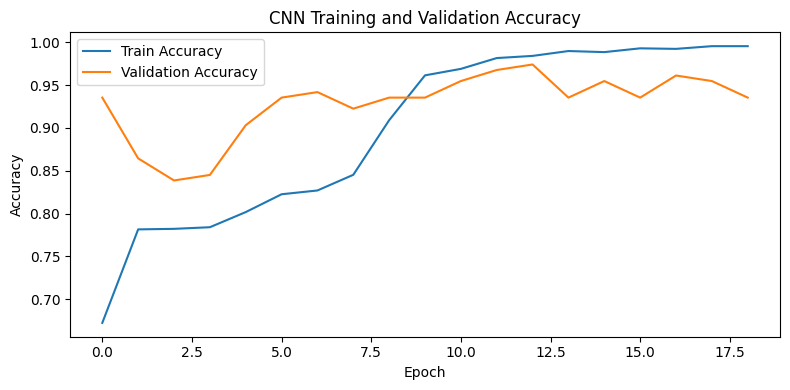

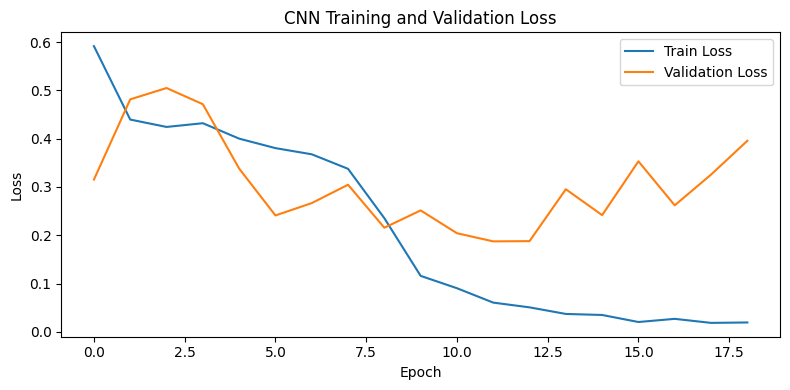

              precision    recall  f1-score   support

    non_wasp       0.97      1.00      0.98       145
        wasp       1.00      0.50      0.67        10

    accuracy                           0.97       155
   macro avg       0.98      0.75      0.82       155
weighted avg       0.97      0.97      0.96       155



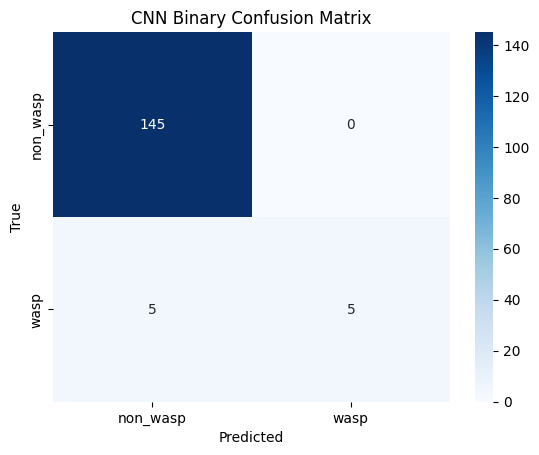

{'Model': 'CNN', 'Accuracy': 0.967741935483871, 'Precision': 0.9833333333333334, 'Recall': 0.75, 'Macro F1': 0.8248587570621468, 'Wasp Recall': 0.5, 'Wasp Precision': 1.0, 'False Negative': 5, 'False Positive': 0, 'False Positive Rate': 0.0}


In [23]:
'''
CNN Validation 평가
'''

# 클래스별 확률을 예측
cnn_val_pred_probs = cnn_model.predict(X_val_cnn, verbose = 0)

# 말벌 확률이 임계값 이상이면 wasp로 판정
cnn_val_pred_classes = predict_classes(cnn_val_pred_probs, WASP_THRESHOLD)

plot_training_history(cnn_history, 'CNN')

cnn_val_result = evaluate_model(y_val_mel, cnn_val_pred_classes, 'CNN')

## 4-3. MobileNetV2

사전 학습된 MobileNetV2 모델을 활용하여 Mel-Spectrogram을 분류한다

- 입력: 128 x 128 x 3 Mel-Spectrogram
- 출력 클래서: non_wasp / wasp
- ImageNet 사전 학습 가중치를 활용한 Transfer Learning 사용
- MobileNetV2의 기본 특징 추출층은 동결하여 학습
- CNN 모델과 동일한 Train / Val / Test 데이터를 사용

In [24]:
'''
Mel-Spectrogram 기반 MobileNetV2 분류 모델

- ImageNet으로 사전 학습된 MobileNetV2를 특징 추출기로 사용한다.
- 데이터셋이 작기 때문에 기본 MobileNetV2 층은 동결한다.
- 마지막 분류층만 non_wasp / wasp 분류에 맞게 새로 학습한다.
'''

# MobileNetV2 입력 shape
mobilenet_input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

# 사전 학습된 MobileNetV2 불러오기
mobilenet_base = MobileNetV2(
    input_shape = mobilenet_input_shape,
    include_top = False,
    weights = 'imagenet'
)

# 사전 학습된 특징 추출층 동결
mobilenet_base.trainable = False

# 분류 모델 구성
mobilenet_model = models.Sequential([
    layers.Input(shape = mobilenet_input_shape),

    mobilenet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.5),

    layers.Dense(len(CLASSES), activation = 'softmax')
])

mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,098 (8.93 MB)

 Trainable params: 82,114 (320.76 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
'''
MobileNetV2 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# MobileNetV2 모델 저장 경로
MOBILENET_MODEL_PATH = os.path.join(MODEL_DIR, 'mobilenetv2.keras')

# Model Compile
mobilenet_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
mobilenet_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Loss가 가장 낮은 모델 저장
mobilenet_checkpoint = ModelCheckpoint(
    filepath = MOBILENET_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('MobileNetV2 Model Path: ', MOBILENET_MODEL_PATH)

MobileNetV2 Model Path:  E:\AI_First_Team_Project\Buzz\ai_model\models\mobilenetv2.keras


In [26]:
'''
MobileNetV2 학습
'''

mobilenet_history = mobilenet_model.fit(
    X_train_mobile,
    y_train_mel,
    validation_data = (X_val_mobile, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    class_weight = class_weights,
    callbacks = [mobilenet_early_stopping, mobilenet_checkpoint],
    verbose = 1
)

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8202 - loss: 0.4136
Epoch 1: val_loss improved from None to 0.16034, saving model to E:\AI_First_Team_Project\Buzz\ai_model\models\mobilenetv2.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - accuracy: 0.8624 - loss: 0.3165 - val_accuracy: 0.9806 - val_loss: 0.1603
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9087 - loss: 0.2430
Epoch 2: val_loss improved from 0.16034 to 0.14519, saving model to E:\AI_First_Team_Project\Buzz\ai_model\models\mobilenetv2.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - accuracy: 0.9097 - loss: 0.2355 - val_accuracy: 0.9806 - val_loss: 0.1452
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9179 - loss: 0.2130
Epoch 3: val_loss did not improve from 0.14519
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.9205 - loss: 0.2099 - val_accuracy: 0.9032 - val_loss: 0.2671
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9187 - loss: 0.199

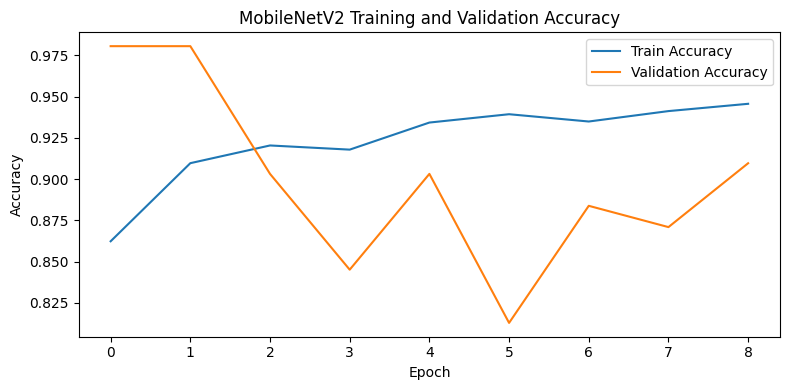

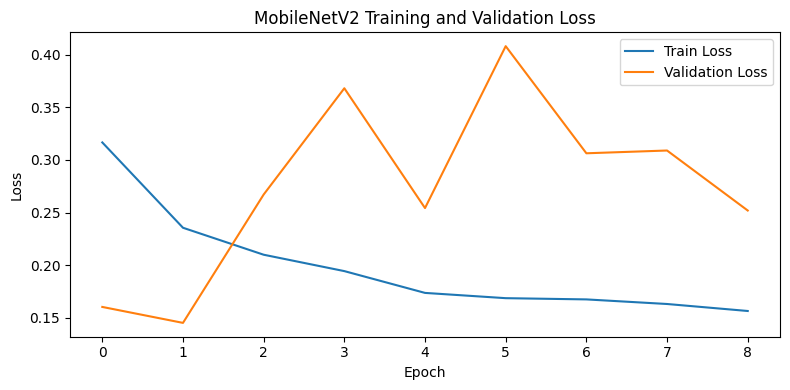

              precision    recall  f1-score   support

    non_wasp       1.00      0.98      0.99       145
        wasp       0.77      1.00      0.87        10

    accuracy                           0.98       155
   macro avg       0.88      0.99      0.93       155
weighted avg       0.99      0.98      0.98       155



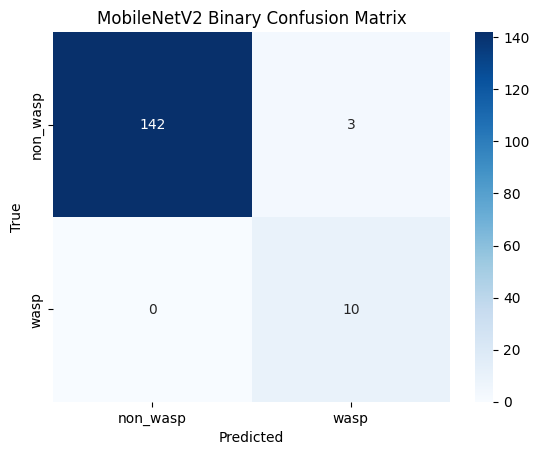

{'Model': 'MobileNetV2', 'Accuracy': 0.9806451612903225, 'Precision': 0.8846153846153846, 'Recall': 0.9896551724137931, 'Macro F1': 0.9295561278594152, 'Wasp Recall': 1.0, 'Wasp Precision': 0.7692307692307693, 'False Negative': 0, 'False Positive': 3, 'False Positive Rate': 0.020689655172413793}


In [27]:
'''
MobileNetV2 Validation 평가
'''

# 클래스 별 확률 예측
mobilenet_val_pred_probs = mobilenet_model.predict(X_val_mobile, verbose = 0)

# 말벌 확률이 임계값 이상이면 wasp로 판정
mobilenet_val_pred_classes = predict_classes(mobilenet_val_pred_probs, WASP_THRESHOLD)

plot_training_history(mobilenet_history, 'MobileNetV2')

mobilenet_val_result = evaluate_model(y_val_mel, mobilenet_val_pred_classes, 'MobileNetV2')

## 4-4. CRNN

Mel-Spectrogram의 공간적 특징과 시간적 변화를 함께 학습하기 위해 CNN과 RNN을 결합한 CRNN 모델을 구성한다.

- CNN을 통해 주파수 패턴의 특징을 추출
- RNN(GRU)을 통해 시간에 따른 특징 변화를 학습
- 출력 클래스: non_wasp / wasp
- CNN, MobileNetV2와 동일한 Train / Val / Test 데이터 사용

In [28]:
'''
Mel-Spectrogram 기반 CRNN 분류 모델

- CNN으로 Mel-Spectrogram의 주요 특징을 추출한다.
- GRU를 사용하여 시간에 따른 특징 변화를 학습한다.
- non_wasp / wasp 2개 클래스를 분류한다.
'''

# CRNN 입력 shape
crnn_input_shape = X_train_crnn.shape[1:]

# 입력층
crnn_input = layers.Input(shape = crnn_input_shape)

# =========================
# CNN Feature 추출
# =========================

x = layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same')(crnn_input)
x = layers.MaxPooling2D(pool_size = (2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(x)
x = layers.MaxPooling2D(pool_size = (2, 2))(x)

# =========================
# CNN → RNN 형태 변환
# =========================

# 현재 CNN 출력 shape에서 시간 축을 sequence로 사용하도록 변환
shape = x.shape

x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

x = layers.Dense(128, activation = 'relu')(x)

# =========================
# GRU
# =========================

x = layers.GRU(64)(x)

# =========================
# Classification
# =========================

x = layers.Dense(64, activation = 'relu')(x)
x = layers.Dropout(0.5)(x)

crnn_output = layers.Dense(len(CLASSES), activation = 'softmax')(x)
crnn_model = models.Model(inputs = crnn_input, outputs = crnn_output)

crnn_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 188, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 188, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 94, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 47, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 47, 128)        │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,626 (1.23 MB)

 Trainable params: 322,626 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
'''
CRNN 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# CRNN 모델 저장 경로
CRNN_MODEL_PATH = os.path.join(MODEL_DIR, 'crnn.keras')

# 모델 컴파일
crnn_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
crnn_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Loss가 가장 낮은 모델 저장
crnn_checkpoint = ModelCheckpoint(
    filepath = CRNN_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('CRNN Model Path: ', CRNN_MODEL_PATH)

CRNN Model Path:  E:\AI_First_Team_Project\Buzz\ai_model\models\crnn.keras


In [30]:
'''
CRNN 모델 학습
'''

crnn_history = crnn_model.fit(
    X_train_crnn,
    y_train_mel,
    validation_data = (X_val_crnn, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    class_weight = class_weights,
    callbacks = [crnn_early_stopping, crnn_checkpoint],
    verbose = 1
)

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.5269 - loss: 0.6592
Epoch 1: val_loss improved from None to 0.58326, saving model to E:\AI_First_Team_Project\Buzz\ai_model\models\crnn.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 15s 127ms/step - accuracy: 0.6383 - loss: 0.5945 - val_accuracy: 0.9097 - val_loss: 0.5833
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7500 - loss: 0.5034
Epoch 2: val_loss improved from 0.58326 to 0.49478, saving model to E:\AI_First_Team_Project\Buzz\ai_model\models\crnn.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.7424 - loss: 0.4935 - val_accuracy: 0.9226 - val_loss: 0.4948
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7721 - loss: 0.4908
Epoch 3: val_loss improved from 0.49478 to 0.47280, saving model to E:\AI_First_Team_Project\Buzz\ai_model\models\crnn.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - accuracy: 0.7563 - loss: 0.4855 - val_accuracy: 0.9355 - val_loss: 0.4728
Epoch 4/50
99/99

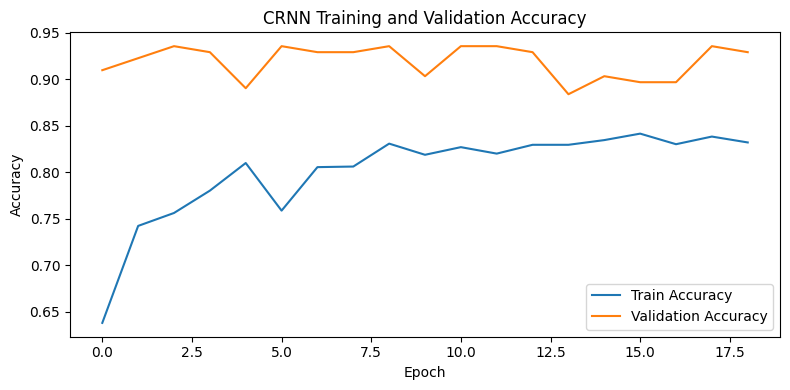

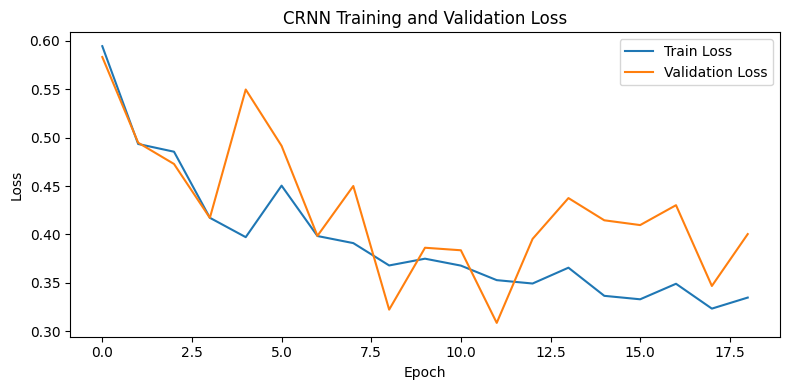

              precision    recall  f1-score   support

    non_wasp       0.94      1.00      0.97       145
        wasp       0.00      0.00      0.00        10

    accuracy                           0.94       155
   macro avg       0.47      0.50      0.48       155
weighted avg       0.88      0.94      0.90       155



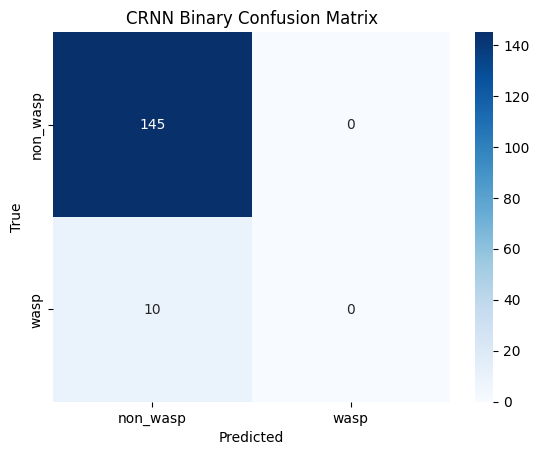

{'Model': 'CRNN', 'Accuracy': 0.9354838709677419, 'Precision': 0.46774193548387094, 'Recall': 0.5, 'Macro F1': 0.48333333333333334, 'Wasp Recall': 0.0, 'Wasp Precision': 0.0, 'False Negative': 10, 'False Positive': 0, 'False Positive Rate': 0.0}


In [31]:
'''
CRNN Validation 평가
'''

# 클래스 별 확률 예측
crnn_val_pred_probs = crnn_model.predict(X_val_crnn, verbose = 0)

# 말벌 확률이 임계값 이상이면 wasp로 판정
crnn_val_pred_classes = predict_classes(crnn_val_pred_probs, WASP_THRESHOLD)

plot_training_history(crnn_history, 'CRNN')

crnn_val_result = evaluate_model(y_val_mel, crnn_val_pred_classes, 'CRNN')

# 5. Machine Learning

## 5-1. Feature 추출

오디오 파일에서 전통적인 머신러닝 모델이 사용할 수 있도록 고정 길이의 음향 특징을 추출한다.

사용 특징:
- MFCC
- Chroma
- Spectral Centroid
- Spectral Bandwidth
- Spectral Rolloff
- Zero Crossing Rate
- RMS

In [ ]:
# ML 특징은 Mel 특징과 동일한 파형으로 이미 생성했습니다.


In [32]:
print('ML features:', X_ml.shape, 'labels:', y_ml.shape)

ML features: (2000, 74) labels: (2000,)


In [33]:
# DL과 정확히 같은 source 분할 사용
X_train_ml, X_val_ml, X_test_ml = [X_ml[i].copy() for i in (train_indices, val_indices, test_indices)]
y_train_ml, y_val_ml, y_test_ml = [y_ml[i] for i in (train_indices, val_indices, test_indices)]
# DL에서 교체한 것과 정확히 같은 위치에 동일 혼합음의 ML 특징을 적용합니다.
if replacement_positions:
    X_train_ml[replacement_positions] = np.asarray(replacement_ml, dtype=np.float32)
np.testing.assert_array_equal(X_val_ml, X_ml[val_indices])
np.testing.assert_array_equal(X_test_ml, X_ml[test_indices])
assert len(X_train_ml) == len(X_train_mel)
assert np.array_equal(y_train_ml, y_train_mel), 'DL/ML 학습 라벨이 일치해야 합니다.'
ml_sample_weights = compute_sample_weight('balanced', y_train_ml)

## 5-2. Random Forest

- RandomForest
> 여러 개의 Decision Tree를 구성하고, 각 Tree의 예측 결과를 종합하여 최종 클래스를 결정하는 앙상블 기반 머신러닝 모델.

In [34]:
'''
RF 분류 모델 학습
'''

rf_model = RandomForestClassifier(n_estimators = 200, random_state = SEED, n_jobs = -1, class_weight = 'balanced')

rf_model.fit(X_train_ml, y_train_ml)

print('RandomForest 학습 완료')

RandomForest 학습 완료


              precision    recall  f1-score   support

    non_wasp       1.00      0.99      0.99       145
        wasp       0.83      1.00      0.91        10

    accuracy                           0.99       155
   macro avg       0.92      0.99      0.95       155
weighted avg       0.99      0.99      0.99       155



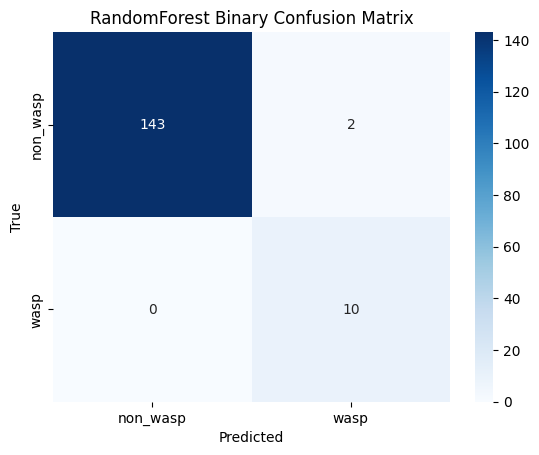

{'Model': 'RandomForest', 'Accuracy': 0.9870967741935484, 'Precision': 0.9166666666666667, 'Recall': 0.993103448275862, 'Macro F1': 0.9510732323232323, 'Wasp Recall': 1.0, 'Wasp Precision': 0.8333333333333334, 'False Negative': 0, 'False Positive': 2, 'False Positive Rate': 0.013793103448275862}


In [35]:
'''
RandomForest Validation 평가
'''

# 예측
rf_val_pred_classes = predict_classes(ordered_ml_probabilities(rf_model, X_val_ml), WASP_THRESHOLD)

rf_val_result = evaluate_model(y_val_ml, rf_val_pred_classes, 'RandomForest')

## 5-3. LightGBM

- Light GBM
> Gradient Boosting 기반의 머신러닝 모델.  
> 여러개의 Decision Tree를 순차적으로 학습하면서 이전 Tree의 오차를 보완하는 방식으로 성능을 개선

In [36]:
'''
LightGBM 분류 모델 학습
'''

lgbm_model = LGBMClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    random_state = SEED,
    verbosity = -1,
    objective = 'binary'
)

lgbm_model.fit(X_train_ml, y_train_ml, sample_weight=ml_sample_weights)

print('LightGBM 학습 완료')

LightGBM 학습 완료


              precision    recall  f1-score   support

    non_wasp       0.98      1.00      0.99       145
        wasp       1.00      0.70      0.82        10

    accuracy                           0.98       155
   macro avg       0.99      0.85      0.91       155
weighted avg       0.98      0.98      0.98       155



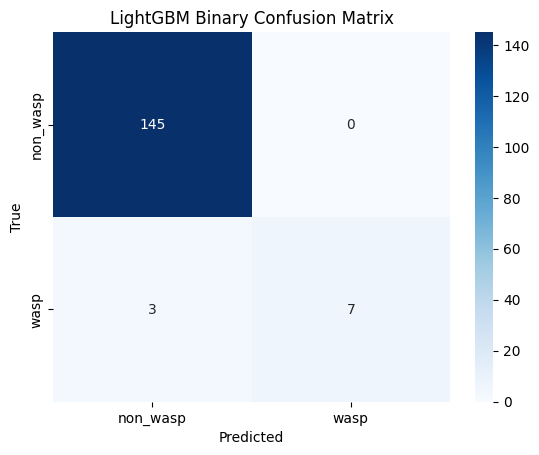

{'Model': 'LightGBM', 'Accuracy': 0.9806451612903225, 'Precision': 0.9898648648648649, 'Recall': 0.85, 'Macro F1': 0.9066452519574382, 'Wasp Recall': 0.7, 'Wasp Precision': 1.0, 'False Negative': 3, 'False Positive': 0, 'False Positive Rate': 0.0}


In [37]:
'''
LightGBM Validation 평가
'''

lgbm_val_pred_classes = predict_classes(ordered_ml_probabilities(lgbm_model, X_val_ml), WASP_THRESHOLD)

lgbm_val_result = evaluate_model(y_val_ml, lgbm_val_pred_classes, 'LightGBM')

## 5-4. XGBoost

- XGBoost
> Gradient Boosting 기반의 머신러닝 모델.  
> 여러 개의 Decision Tree를 순차적으로 학습하면서 이전 모델의 오차를 보완하는 방식으로 성능을 개선

In [38]:
'''
XGBoost 분류 모델 학습
'''

xgb_model = XGBClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = SEED,
    objective = 'binary:logistic',
    eval_metric = 'logloss'
)

xgb_model.fit(X_train_ml, y_train_ml, sample_weight=ml_sample_weights)

print('XGBoost 학습 완료')

XGBoost 학습 완료


              precision    recall  f1-score   support

    non_wasp       0.99      1.00      0.99       145
        wasp       1.00      0.80      0.89        10

    accuracy                           0.99       155
   macro avg       0.99      0.90      0.94       155
weighted avg       0.99      0.99      0.99       155



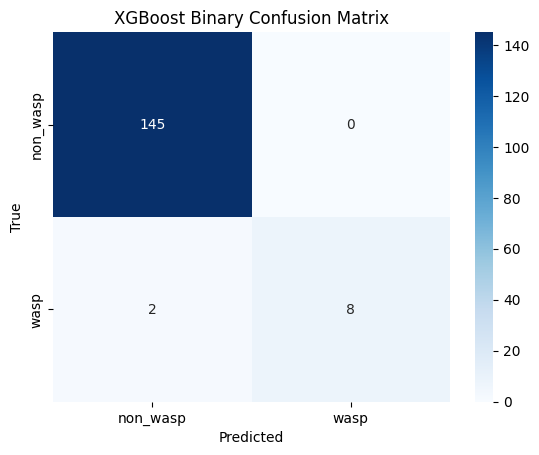

{'Model': 'XGBoost', 'Accuracy': 0.9870967741935484, 'Precision': 0.9931972789115646, 'Recall': 0.9, 'Macro F1': 0.9410197869101978, 'Wasp Recall': 0.8, 'Wasp Precision': 1.0, 'False Negative': 2, 'False Positive': 0, 'False Positive Rate': 0.0}


In [39]:
'''
XGBoost Validation 평가
'''

xgb_val_pred_classes = predict_classes(ordered_ml_probabilities(xgb_model, X_val_ml), WASP_THRESHOLD)

xgb_val_result = evaluate_model(y_val_ml, xgb_val_pred_classes, 'XGBoost')

## 5-5. Machine Learning 모델 저장

In [40]:
ensure_directory_exists(MODEL_DIR)

RF_MODEL_PATH = os.path.join(MODEL_DIR, 'randomforest.pkl')
LGBM_MODEL_PATH = os.path.join(MODEL_DIR, 'lightgbm.pkl')
XGB_MODEL_PATH = os.path.join(MODEL_DIR, 'xgboost.pkl')

joblib.dump(rf_model, RF_MODEL_PATH)
joblib.dump(lgbm_model, LGBM_MODEL_PATH)
joblib.dump(xgb_model, XGB_MODEL_PATH)

print('===== Machine Learning 모델 저장 완료 =====')
print('RandomForest : ', RF_MODEL_PATH)
print('LightGBM     : ', LGBM_MODEL_PATH)
print('XGBoost      : ', XGB_MODEL_PATH)

===== Machine Learning 모델 저장 완료 =====
RandomForest :  E:\AI_First_Team_Project\Buzz\ai_model\models\randomforest.pkl
LightGBM     :  E:\AI_First_Team_Project\Buzz\ai_model\models\lightgbm.pkl
XGBoost      :  E:\AI_First_Team_Project\Buzz\ai_model\models\xgboost.pkl


# 6. 모델 성능 비교 및 최종 추론 방식 선정

학습한 모델들의 Validation 성능을 동일한 평가 지표로 비교

- Accuracy
- Precision
- Recall
- Macro F1
- Wasp Recall

Validation 결과를 기준으로 Best Single Model을 선정하고, 이후 Ensemble 방식과 비교하여 최종 추론 방식을 결정

In [41]:
'''
Validation 기준 모델 성능 비교
'''

validation_results = pd.DataFrame([
    cnn_val_result,
    mobilenet_val_result,
    crnn_val_result,
    rf_val_result,
    lgbm_val_result,
    xgb_val_result
])

# Wasp Recall 우선, Macro F1 보조 기준으로 정렬
validation_results = validation_results.sort_values(
    by = ['Wasp Recall', 'Macro F1'],
    ascending = [False, False]
).reset_index(drop = True)

print('===== Validation 모델 성능 비교 =====')
display(validation_results)

# Best Single Model 선정
best_model_name = validation_results.loc[0, 'Model']

print('===== Best Single Model =====')
print(best_model_name)

===== Validation 모델 성능 비교 =====


,Model,Accuracy,Precision,Recall,Macro F1,Wasp Recall,Wasp Precision,False Negative,False Positive,False Positive Rate
0,RandomForest,0.987097,0.916667,0.993103,0.951073,1.0,0.833333,0,2,0.013793
1,MobileNetV2,0.980645,0.884615,0.989655,0.929556,1.0,0.769231,0,3,0.020690
2,XGBoost,0.987097,0.993197,0.900000,0.941020,0.8,1.000000,2,0,0.000000
3,LightGBM,0.980645,0.989865,0.850000,0.906645,0.7,1.000000,3,0,0.000000
4,CNN,0.967742,0.983333,0.750000,0.824859,0.5,1.000000,5,0,0.000000
5,CRNN,0.935484,0.467742,0.500000,0.483333,0.0,0.000000,10,0,0.000000


===== Best Single Model =====
RandomForest


              precision    recall  f1-score   support

    non_wasp       0.99      1.00      0.99       145
        wasp       1.00      0.80      0.89        10

    accuracy                           0.99       155
   macro avg       0.99      0.90      0.94       155
weighted avg       0.99      0.99      0.99       155



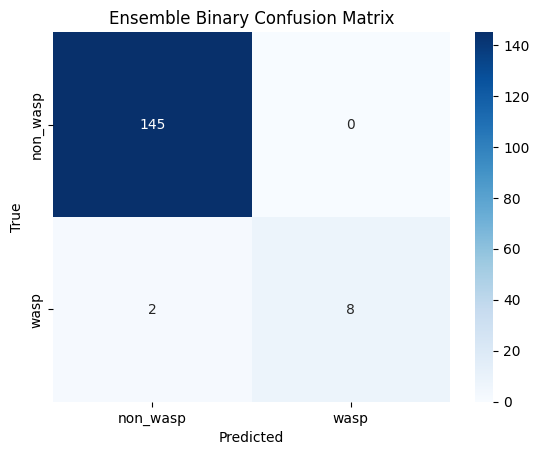

{'Model': 'Ensemble', 'Accuracy': 0.9870967741935484, 'Precision': 0.9931972789115646, 'Recall': 0.9, 'Macro F1': 0.9410197869101978, 'Wasp Recall': 0.8, 'Wasp Precision': 1.0, 'False Negative': 2, 'False Positive': 0, 'False Positive Rate': 0.0}


In [42]:
'''
Soft Voting Ensemble Validation 평가

6개 모델의 클래스별 예측 확률을 평균하여 최종 클래스를 결정
'''

# Machine Learning 모델의 Validation 예측 확률
rf_val_pred_probs = ordered_ml_probabilities(rf_model, X_val_ml)
lgbm_val_pred_probs = ordered_ml_probabilities(lgbm_model, X_val_ml)
xgb_val_pred_probs = ordered_ml_probabilities(xgb_model, X_val_ml)

# Deep Learning + Machine Learning 6개 모델의 확률 평균
ensemble_val_pred_probs = np.mean([
    cnn_val_pred_probs,
    mobilenet_val_pred_probs,
    crnn_val_pred_probs,
    rf_val_pred_probs,
    lgbm_val_pred_probs,
    xgb_val_pred_probs
], axis = 0)

# 평균 말벌 확률에 공통 임계값 적용
ensemble_val_pred_classes = predict_classes(ensemble_val_pred_probs, WASP_THRESHOLD)

# Ensemble Validation 성능 평가
ensemble_val_result = evaluate_model(y_val_mel, ensemble_val_pred_classes, 'Ensemble')

In [43]:
'''
Best Single Model vs Ensemble 비교

Validation 성능을 기준으로 최종 추론 방식 결정
'''

# Best Single Model 결과
best_single_result = validation_results.iloc[0].to_dict()

# 비교용 DataFrame
final_method_results = pd.DataFrame([
    best_single_result,
    ensemble_val_result
])

# Wasp Recall 우선, Macro F1 보조 기준
final_method_results = final_method_results.sort_values(
    by = ['Wasp Recall', 'Macro F1'],
    ascending = [False, False]
).reset_index(drop = True)

print('===== Best Single Model vs Ensemble =====')
display(final_method_results)

# 최종 추론 방식 결정
final_method_name = final_method_results.loc[0, 'Model']

if final_method_name == 'Ensemble':
    final_inference_type = 'ensemble'
    final_model_name = None
else:
    final_inference_type = 'single'
    final_model_name = final_method_name

print('===== 최종 추론 방식 =====')
if final_inference_type == 'ensemble':
    print('Ensemble')
else:
    print(f'Best Single Model : {final_model_name}')

===== Best Single Model vs Ensemble =====


,Model,Accuracy,Precision,Recall,Macro F1,Wasp Recall,Wasp Precision,False Negative,False Positive,False Positive Rate
0,RandomForest,0.987097,0.916667,0.993103,0.951073,1.0,0.833333,0,2,0.013793
1,Ensemble,0.987097,0.993197,0.900000,0.941020,0.8,1.000000,2,0,0.000000


===== 최종 추론 방식 =====
Best Single Model : RandomForest


              precision    recall  f1-score   support

    non_wasp       1.00      0.33      0.50       150
        wasp       0.53      1.00      0.69       111

    accuracy                           0.62       261
   macro avg       0.76      0.67      0.59       261
weighted avg       0.80      0.62      0.58       261



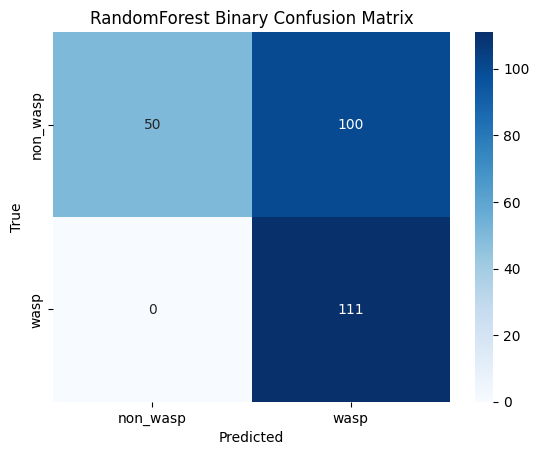

{'Model': 'RandomForest', 'Accuracy': 0.6168582375478927, 'Precision': 0.7630331753554502, 'Recall': 0.6666666666666666, 'Macro F1': 0.59472049689441, 'Wasp Recall': 1.0, 'Wasp Precision': 0.5260663507109005, 'False Negative': 0, 'False Positive': 100, 'False Positive Rate': 0.6666666666666666}
===== 최종 Test 결과 =====
최종 추론 방식 : RandomForest


In [44]:
'''
최종 추론 방식 Test 평가

Validation에서 결정된 최종 추론 방식을 Test 데이터로 마지막 한 번 더 평가
'''

if final_inference_type == 'ensemble':
    # Deep Learning 모델 Test 예측 확률
    cnn_test_pred_probs = cnn_model.predict(X_test_cnn, verbose = 0)
    mobilenet_test_pred_probs = mobilenet_model.predict(X_test_mobile, verbose = 0)
    crnn_test_pred_probs = crnn_model.predict(X_test_crnn, verbose = 0)

    # Machine Learning 모델 Test 예측 확률
    rf_test_pred_probs = ordered_ml_probabilities(rf_model, X_test_ml)
    lgbm_test_pred_probs = ordered_ml_probabilities(lgbm_model, X_test_ml)
    xgb_test_pred_probs = ordered_ml_probabilities(xgb_model, X_test_ml)

    # Soft Voting
    final_test_pred_probs = np.mean([
        cnn_test_pred_probs,
        mobilenet_test_pred_probs,
        crnn_test_pred_probs,
        rf_test_pred_probs,
        lgbm_test_pred_probs,
        xgb_test_pred_probs
    ], axis = 0)

    final_test_pred_classes = predict_classes(final_test_pred_probs, WASP_THRESHOLD)

    final_test_name = 'Ensemble'
else:
    if final_model_name == 'CNN':
        final_test_pred_probs = cnn_model.predict(X_test_cnn, verbose = 0)
        final_test_pred_classes = predict_classes(final_test_pred_probs, WASP_THRESHOLD)
    elif final_model_name == 'MobileNetV2':
        final_test_pred_probs = mobilenet_model.predict(X_test_mobile, verbose = 0)
        final_test_pred_classes = predict_classes(final_test_pred_probs, WASP_THRESHOLD)
    elif final_model_name == 'CRNN':
        final_test_pred_probs = crnn_model.predict(X_test_crnn, verbose = 0)
        final_test_pred_classes = predict_classes(final_test_pred_probs, WASP_THRESHOLD)
    elif final_model_name == 'RandomForest':
        final_test_pred_probs = ordered_ml_probabilities(rf_model, X_test_ml)
        final_test_pred_classes = predict_classes(ordered_ml_probabilities(rf_model, X_test_ml), WASP_THRESHOLD)
    elif final_model_name == 'LightGBM':
        final_test_pred_probs = ordered_ml_probabilities(lgbm_model, X_test_ml)
        final_test_pred_classes = predict_classes(ordered_ml_probabilities(lgbm_model, X_test_ml), WASP_THRESHOLD)
    elif final_model_name == 'XGBoost':
        final_test_pred_probs = ordered_ml_probabilities(xgb_model, X_test_ml)
        final_test_pred_classes = predict_classes(ordered_ml_probabilities(xgb_model, X_test_ml), WASP_THRESHOLD)
    else:
        raise ValueError(f'지원하지 않는 모델입니다: {final_model_name}')

    final_test_name = final_model_name

# 최종 Test 평가
final_test_result = evaluate_model(y_test_mel, final_test_pred_classes, final_test_name)

print('===== 최종 Test 결과 =====')
print(f'최종 추론 방식 : {final_test_name}')

import json
with (MODEL_DIR / 'training_summary.json').open('w', encoding='utf-8') as handle:
    json.dump({
        'classes': CLASSES, 'sampleRate': SR, 'duration': DURATION,
        'waspThreshold': WASP_THRESHOLD, 'seed': SEED,
        'inferenceType': final_inference_type, 'modelName': final_model_name,
        'testMetrics': final_test_result,
        'mixing': mixing_summary,
    }, handle, ensure_ascii=False, indent=2)

# 7. 최종 추론 및 UI 데이터 생성

임의의 WAV 파일 하나를 입력받아 모델 예측 결과와
UI 시각화에 필요한 Waveform, FFT, Spectrogram 데이터를 생성한다.

반환 데이터:
- 예측 클래스
- 예측 확률
- 클래스별 확률
- Waveform
- FFT
- Mel-Spectrogram

In [45]:
from src.visualization import create_audio_visualization_data
# 그래프도 src의 공통 구현을 사용한다.


In [ ]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [ ]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [ ]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [ ]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [ ]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [46]:
from src.inference import analyze_audio as analyze_binary_audio

trained_models = {
    'CNN': cnn_model, 'MobileNetV2': mobilenet_model, 'CRNN': crnn_model,
    'RandomForest': rf_model, 'LightGBM': lgbm_model, 'XGBoost': xgb_model,
}

def analyze_audio(audio_path, offset=0.0):
    return analyze_binary_audio(
        audio_path, trained_models, final_inference_type, final_model_name,
        threshold=WASP_THRESHOLD, offset=offset,
    )

In [47]:
# 최종 Test 중 한 구간의 실제 파형/이진 확률 확인
# 별도 시연 음원은 경로를 바꾸고 offset(초)을 지정한다.
test_audio_path = str(paths_test_mel[0])
result = analyze_audio(test_audio_path)
print('파일:', test_audio_path)
print('모델:', result['meta']['modelName'])
print('판정:', result['prediction']['label'])
print('확률:', result['prediction']['probabilities'])
print('말벌 임계값:', result['meta']['waspThreshold'])

파일: E:\AI_First_Team_Project\Buzz\ai_model\audio\non_wasp\bee3(env)\bee3_001.wav
모델: RandomForest
판정: wasp
확률: {'non_wasp': 0.115, 'wasp': 0.885}
말벌 임계값: 0.5
